In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [3]:
training_set = train_datagen.flow_from_directory('dataset/train',
                                                 target_size = (128, 128),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

labels = (training_set.class_indices)
print(labels)

test_set = test_datagen.flow_from_directory('dataset/test',
                                            target_size = (128, 128),
                                            batch_size = 32,
                                            class_mode = 'categorical')

labels2 = (test_set.class_indices)
print(labels2)

Found 375 images belonging to 25 classes.
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___Healthy': 3, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 4, 'Corn_(maize)___Common_rust': 5, 'Corn_(maize)___Healthy': 6, 'Corn_(maize)___Northern_Leaf_Blight': 7, 'Grape___Black_rot': 8, 'Grape___Esca_(Black_Measles)': 9, 'Grape___Healthy': 10, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 11, 'Potato___Early_blight': 12, 'Potato___Healthy': 13, 'Potato___Late_blight': 14, 'Tomato___Bacterial_spot': 15, 'Tomato___Early_blight': 16, 'Tomato___Healthy': 17, 'Tomato___Late_blight': 18, 'Tomato___Leaf_Mold': 19, 'Tomato___Septoria_leaf_spot': 20, 'Tomato___Spider_mites Two-spotted_spider_mite': 21, 'Tomato___Target_Spot': 22, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 23, 'Tomato___Tomato_mosaic_virus': 24}
Found 127 images belonging to 25 classes.


{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___Healthy': 3, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 4, 'Corn_(maize)___Common_rust_': 5, 'Corn_(maize)___Healthy': 6, 'Corn_(maize)___Northern_Leaf_Blight': 7, 'Grape___Black_rot': 8, 'Grape___Esca_(Black_Measles)': 9, 'Grape___Healthy': 10, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 11, 'Potato___Early_blight': 12, 'Potato___Healthy': 13, 'Potato___Late_blight': 14, 'Tomato___Bacterial_spot': 15, 'Tomato___Early_blight': 16, 'Tomato___Healthy': 17, 'Tomato___Late_blight': 18, 'Tomato___Leaf_Mold': 19, 'Tomato___Septoria_leaf_spot': 20, 'Tomato___Spider_mites Two-spotted_spider_mite': 21, 'Tomato___Target_Spot': 22, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 23, 'Tomato___Tomato_mosaic_virus': 24}


In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

In [5]:
base_model.trainable = False

In [6]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Flattens the 2D feature maps into a 1D vector
    Dense(256, activation='relu'),
    Dropout(0.5),             # Stronger dropout to fight overfitting on your small dataset
    Dense(25, activation='softmax')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    training_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 407ms/step - accuracy: 0.1360 - loss: 3.3595 - val_accuracy: 0.4016 - val_loss: 2.3639
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 293ms/step - accuracy: 0.3413 - loss: 2.1735 - val_accuracy: 0.5984 - val_loss: 1.7592
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.5467 - loss: 1.5616 - val_accuracy: 0.6693 - val_loss: 1.3643
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 0.6080 - loss: 1.3078 - val_accuracy: 0.7480 - val_loss: 1.1456
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.7733 - loss: 0.9060 - val_accuracy: 0.7480 - val_loss: 1.0309
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.7707 - loss: 0.8173 - val_accuracy: 0.7559 - val_loss: 0.9401
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.7840 - loss: 0.6996 - val_accuracy: 0.7874 - val_loss: 0.8712
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 0.8187 - loss: 0.6417 - val_accuracy: 0.

In [9]:
import tensorflow as tf

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(training_set, epochs=5, validation_data=test_set)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 439ms/step - accuracy: 0.4053 - loss: 2.3973 - val_accuracy: 0.7953 - val_loss: 0.7743
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - accuracy: 0.4320 - loss: 2.1248 - val_accuracy: 0.8110 - val_loss: 0.7546
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.4720 - loss: 1.8850 - val_accuracy: 0.8110 - val_loss: 0.7396
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.4533 - loss: 1.8485 - val_accuracy: 0.8110 - val_loss: 0.7306
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.5013 - loss: 1.7480 - val_accuracy: 0.8110 - val_loss: 0.7222


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


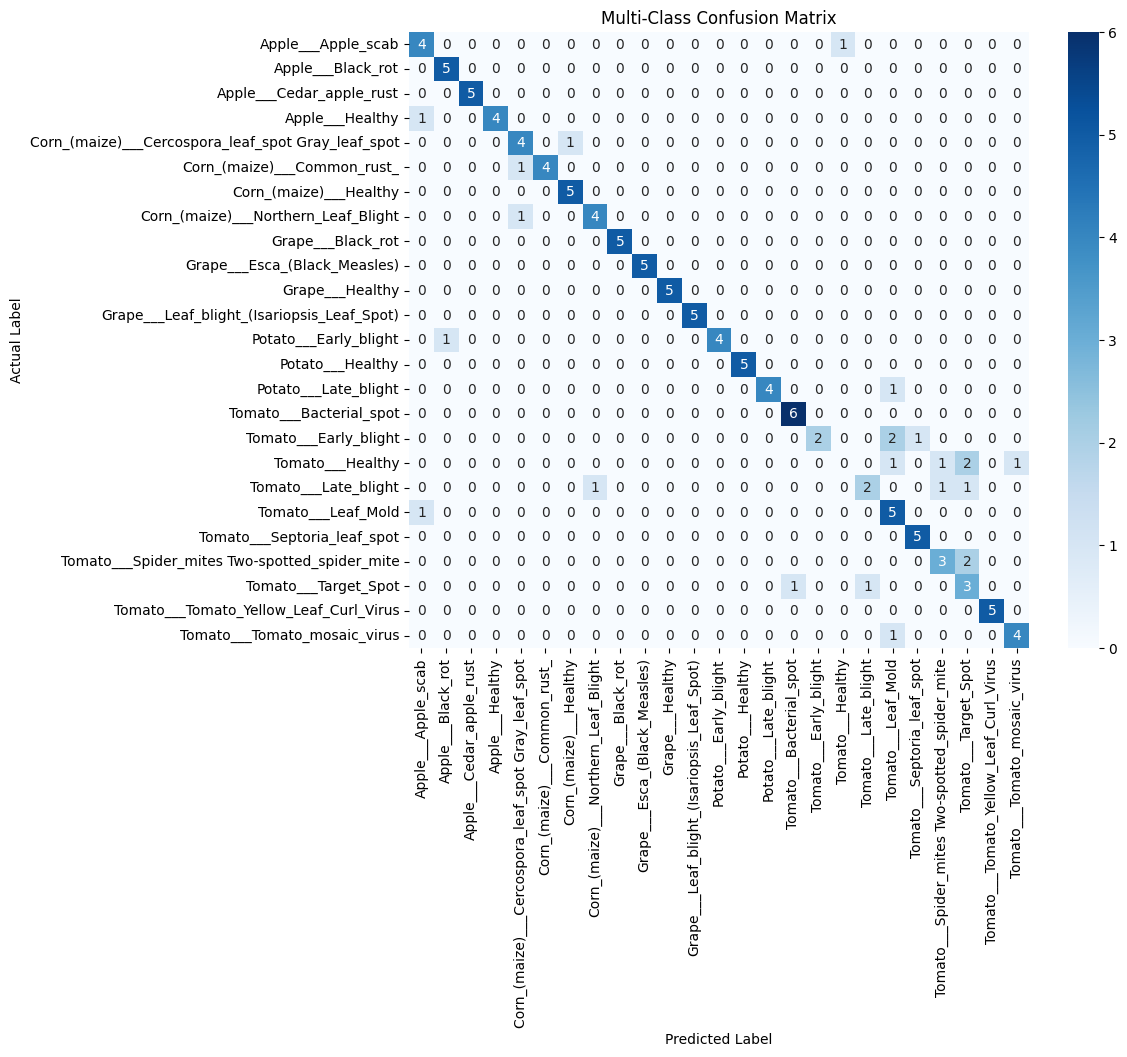

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.67      0.80      0.73         5
                                 Apple___Black_rot       0.83      1.00      0.91         5
                          Apple___Cedar_apple_rust       1.00      1.00      1.00         5
                                   Apple___Healthy       1.00      0.80      0.89         5
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.67      0.80      0.73         5
                       Corn_(maize)___Common_rust_       1.00      0.80      0.89         5
                            Corn_(maize)___Healthy       0.83      1.00      0.91         5
               Corn_(maize)___Northern_Leaf_Blight       0.80      0.80      0.80         5
                                 Grape___Black_rot       1.00      1.00      1.00         5
                      Grape___Esca_(Black_Measles)       1.00      1.00      1.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure the generator is at the start and not shuffled
test_set.reset()
test_set.shuffle = False

# 1. Predict probabilities for all classes
predictions = model.predict(test_set)

# 2. Get the index of the highest probability for each sample
y_pred = np.argmax(predictions, axis=1)

# 3. Get true labels and class names
y_true = test_set.classes
class_names = list(test_set.class_indices.keys())

# 4. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multi-Class Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Detailed Performance Report
print(classification_report(y_true, y_pred, target_names=class_names))

In [17]:
loss, accuracy = model.evaluate(test_set)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8110 - loss: 0.7222
Test loss: 0.7222432494163513
Test accuracy: 0.8110235929489136


In [18]:
# Save Structure
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# Save Weights
model.save_weights("model.weights.h5")
print("Saved model to disk")


Saved model to disk
